### Task XII:

Complete Task XI using a simple temporal difference algorithm (e.g. PPO, DQN, etc.). Use MSE in the reward function.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

The following cell is critical because the default.qubit simulator in PennyLane defaults to float64. Without this, we would get a RuntimeError during the backward pass due to a type mismatch between the classical (Float32) and quantum (Float64) gradients.

In [3]:
torch.set_default_dtype(torch.float64)
torch.manual_seed(42)

In [4]:
# Data to embed
X = torch.randn(100, 4)

The following code cell defines a hybrid neural network that uses a classical Multi-Layer Perceptron (MLP) to generate rotation parameters for a Variational Quantum Circuit (VQC). During the forward pass, the model adjusts these parameters by a "shift" value before executing the quantum circuit and returning the resulting Pauli-Z expectation values as the final output.

Instead of the quantum circuit parameters being determined solely by the neural network's internal weights, the agent's decision directly "nudges" or modifies those parameters. This setup allows the RL agent to dynamically control the quantum state's evolution, essentially using the quantum circuit as a tunable environment or a parameterized policy that responds to external inputs.

In [5]:
# Hybrid Model (action-controlled)
class HybridModel(nn.Module):
    def __init__(self, n_qubits, n_layers):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.output_dim = n_qubits * 2 * n_layers # total number of parameters

        self.mlp = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, self.output_dim)
        )

        dev = qml.device("default.qubit", wires=n_qubits)

        @qml.qnode(dev, interface="torch")
        def qnode(params):
            params = params.reshape(self.n_layers, self.n_qubits, 2)
            for l in range(self.n_layers):
                for i in range(self.n_qubits):
                    qml.RX(params[l, i, 0], wires=i) # RX parameter layer
                    qml.RY(params[l, i, 1], wires=i) # RY parameter layer
                for i in range(self.n_qubits - 1):
                    qml.CNOT(wires=[i, i+1]) # Entangling layer
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        self.qnode = qnode

    def forward(self, x, shift):
        params_batch = self.mlp(x)
        outputs = []
        for p in params_batch:
            p = p + shift  # action effect
            outputs.append(torch.stack(self.qnode(p)))
        return torch.stack(outputs)[:, :4] # discard the last qubit if 5 qubits are used

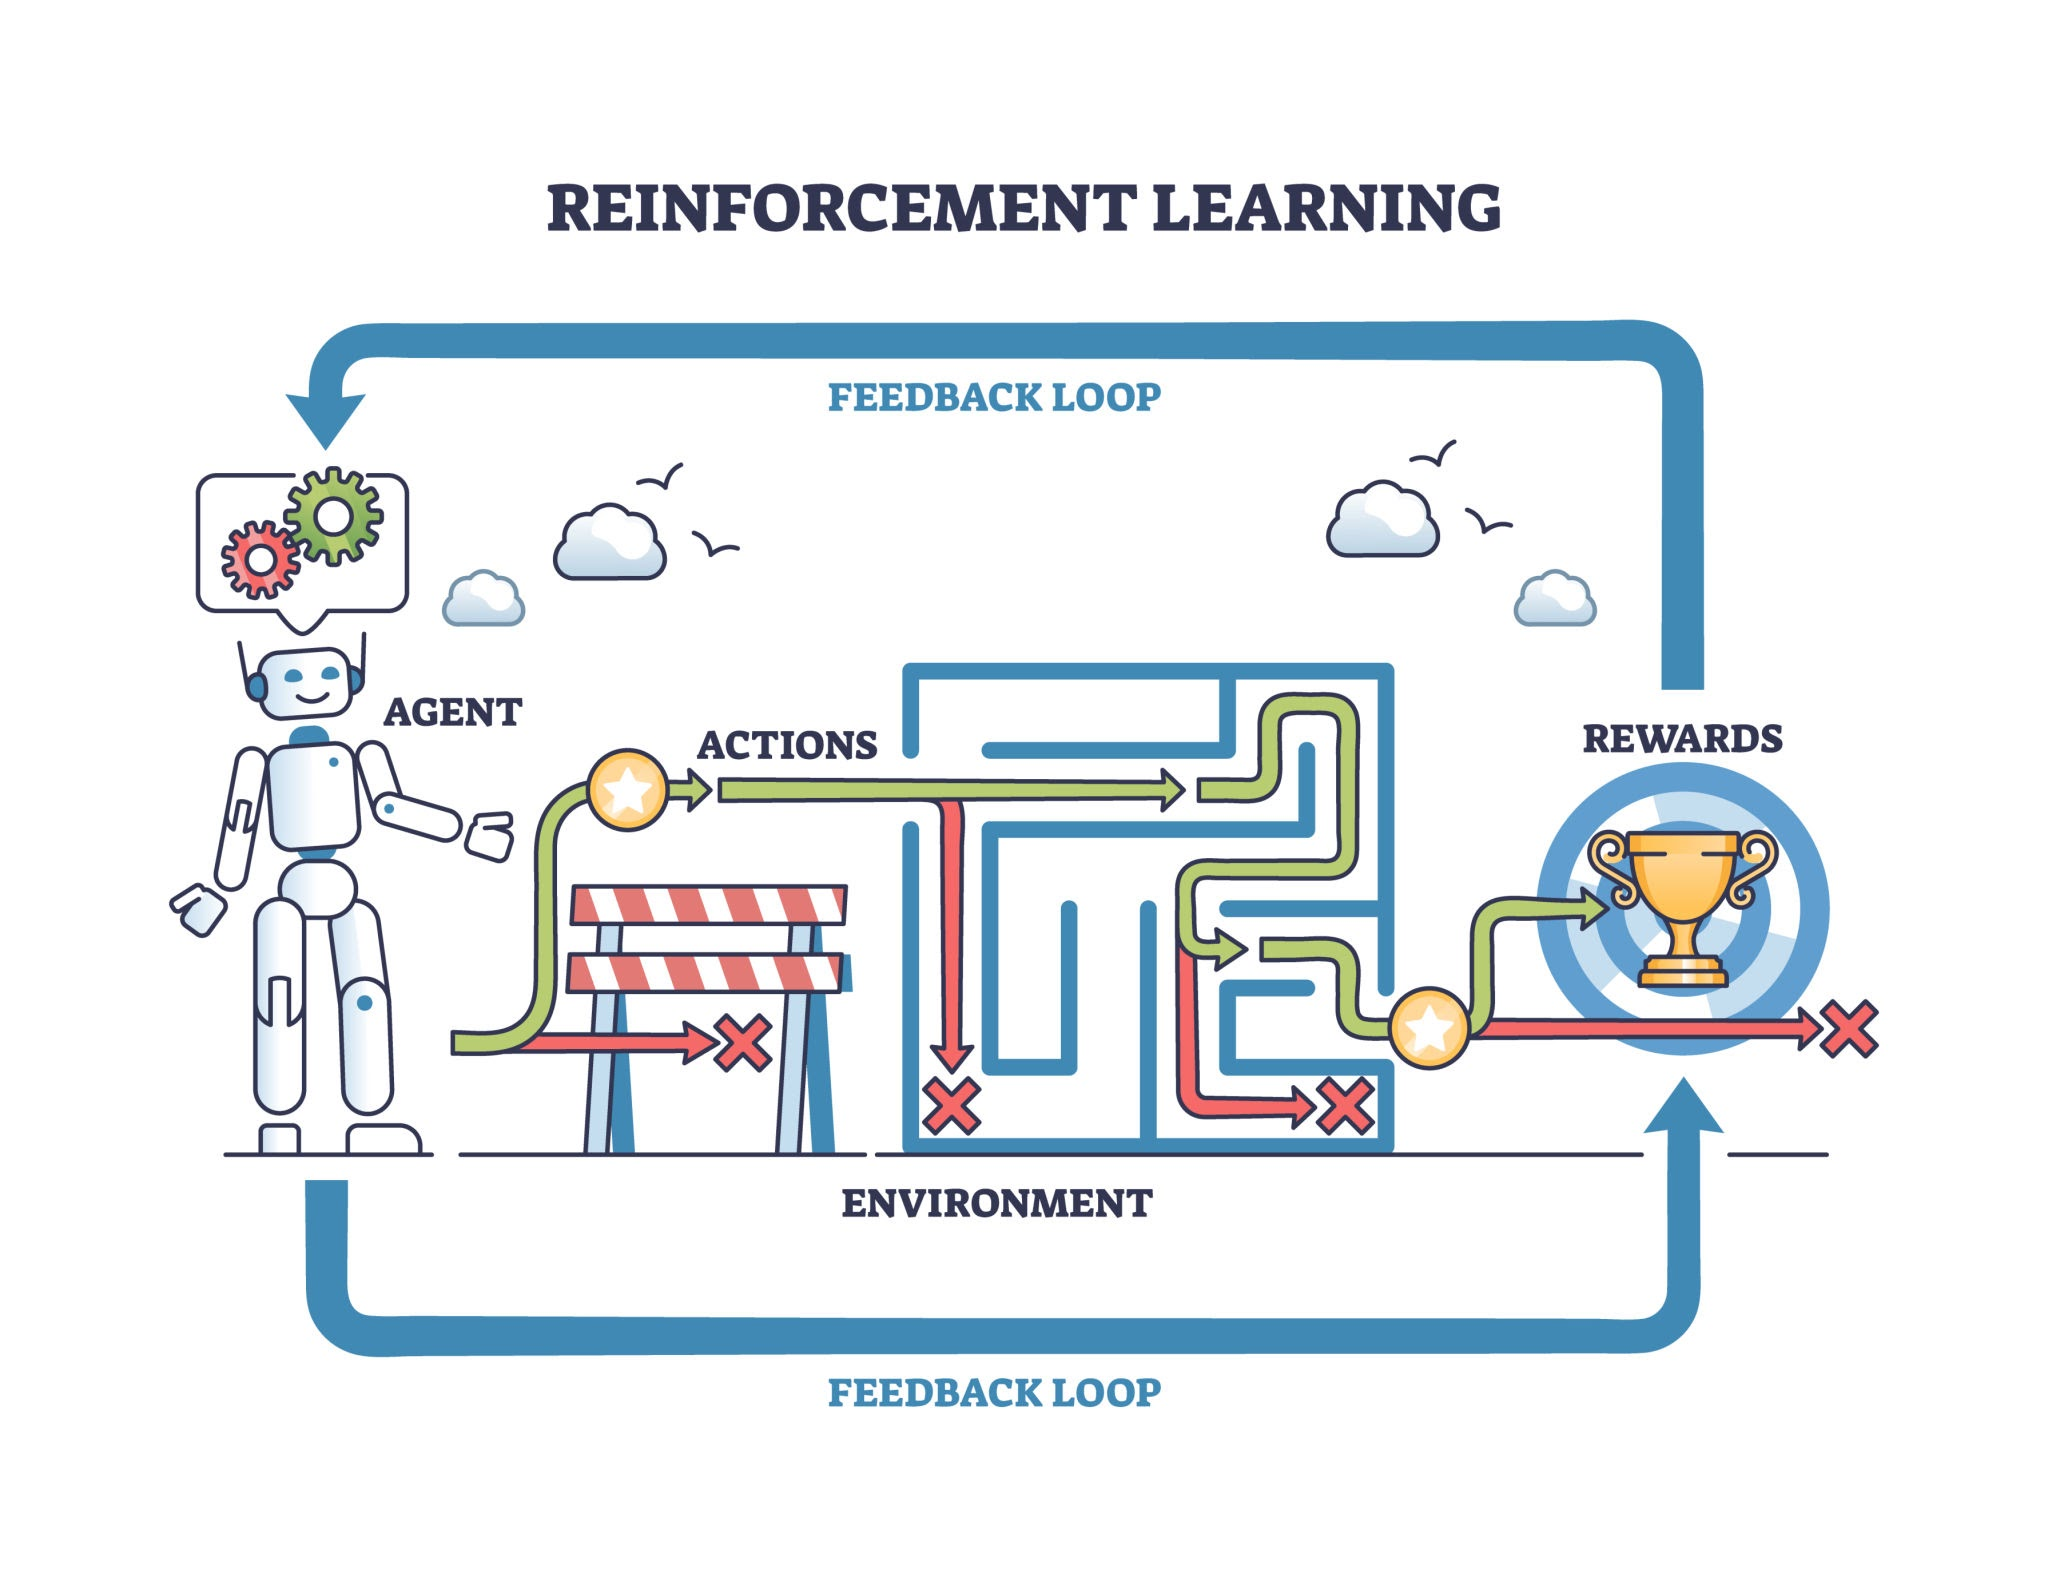

This QuantumEnv class implements a custom reinforcement learning environment where an agent's actions dynamically adjust a shift parameter to minimize the mean squared error between the hybrid model's quantum output and the input data.

In [6]:
# Environment
class QuantumEnv:
    def __init__(self, model, data):
        self.model = model
        self.data = data
        self.idx = 0
        self.shift = 0.0

    def reset(self):
        self.idx = 0
        self.shift = 0.0
        self.state = self.data[self.idx]
        return self.state

    def step(self, action):
        # actions modify circuit behavior
        if action == 0:
            self.shift -= 0.05
        elif action == 2:
            self.shift += 0.05

        x = self.state.unsqueeze(0)
        pred = self.model(x, self.shift).detach()
        mse = torch.mean((pred - x) ** 2)

        reward = -mse  # stable reward

        # Moves the pointer to the next data point in the set, looping back to the start if necessary
        self.idx = (self.idx + 1) % len(self.data)
        next_state = self.data[self.idx]

        return next_state, reward, False

In the context of Deep Q-Learning (DQN), the QNetwork serves as the "brain" of the agent. Its primary job is to look at the current state of the environment and predict the expected future reward for every possible action it could take. By other words it finds the action to perform for each state of the 3 states.

**Output (Q-Values):** It outputs 3 values, one for each possible action:

- **Action 0:** Decrease the quantum shift.

- **Action 1:** Do nothing.

- **Action 2:** Increase the quantum shift.

In [7]:
# Q Network
class QNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.net(x)

The following cell coordinates the Deep Q-Learning (DQN) training process by initializing the hybrid quantum-classical environment and two identical networks—the policy and target networks—to stabilize learning. It uses an epsilon-greedy strategy to balance exploring new actions versus exploiting known rewards while storing experiences in a replay memory to break correlations between consecutive steps. Each training iteration samples a batch of these experiences to update the policy network's weights based on the difference between predicted and future estimated rewards, periodically syncing the target network to ensure consistent training progress.

In [8]:
# Training Function
def run_experiment(n_qubits, n_layers):

    model = HybridModel(n_qubits, n_layers)
    env = QuantumEnv(model, X)

    policy_net = QNetwork()
    target_net = QNetwork()
    target_net.load_state_dict(policy_net.state_dict())

    optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
    memory = deque(maxlen=2000)

    gamma = 0.95
    batch_size = 32

    epsilon = 0.5
    epsilon_decay = 0.98
    epsilon_min = 0.01

    loss_history = []

    def select_action(state):
        if random.random() < epsilon:
            return random.randint(0, 2)
        else:
            with torch.no_grad():
                return torch.argmax(policy_net(state)).item()

    def train_dqn():
        if len(memory) < batch_size:
            return None

        batch = random.sample(memory, batch_size)
        states, actions, rewards, next_states = zip(*batch)

        states = torch.stack(states)
        next_states = torch.stack(next_states)
        actions = torch.tensor(actions)
        rewards = torch.tensor(rewards)

        q_values = policy_net(states)
        current_q = q_values.gather(1, actions.unsqueeze(1)).squeeze()

        with torch.no_grad():
            next_q = target_net(next_states).max(1)[0]
            target_q = rewards + gamma * next_q

        loss = nn.MSELoss()(current_q, target_q)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        return loss.item()

    # Training loop
    for episode in range(100):
        state = env.reset()
        losses = []

        for t in range(50):
            action = select_action(state)
            next_state, reward, _ = env.step(action)

            memory.append((state, action, reward, next_state))

            loss = train_dqn()
            if loss is not None:
                losses.append(loss)

            state = next_state

        if episode % 5 == 0:
            target_net.load_state_dict(policy_net.state_dict())

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        avg_loss = np.mean(losses) if losses else 0
        loss_history.append(avg_loss)

    return loss_history

Running for 4 qubits & 1 layers ...

Running for 4 qubits & 2 layers ...

Running for 5 qubits & 1 layers ...

Running for 5 qubits & 2 layers ...



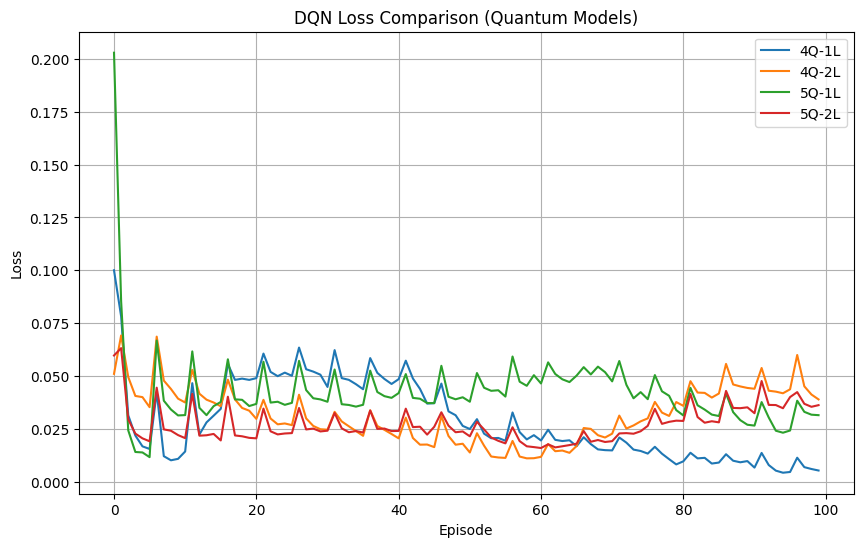


Final Loss Comparison:
-----------------------------------
Configuration   | Final Loss
-----------------------------------
4Q-1L           | 0.005236
4Q-2L           | 0.038882
5Q-1L           | 0.031425
5Q-2L           | 0.036163


In [9]:
# =========================
# Run All Configurations
# =========================
configs = [(4,1), (4,2), (5,1), (5,2)]
results = {}

plt.figure(figsize=(10,6))

for q, l in configs:
    print(f"Running for {q} qubits & {l} layers ...\n")
    label = f"{q}Q-{l}L"
    losses = run_experiment(q, l)
    results[label] = losses[-1]
    plt.plot(losses, label=label)

# =========================
# Plot
# =========================
plt.title("DQN Loss Comparison (Quantum Models)")
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# =========================
# Table Output
# =========================
print("\nFinal Loss Comparison:")
print("-"*35)
print(f"{'Configuration':<15} | {'Final Loss':<10}")
print("-"*35)
for k, v in results.items():
    print(f"{k:<15} | {v:.6f}")